### Es 1
Hai a disposizione un file `data.csv` contenente dati mensili di traffico aereo con due colonne:

- `date`: data in formato `YYYY-MM` (mese/anno)
- `passengers`: numero di passeggeri per quel mese


Costruisci un modello di **regressione polinomiale** che approssima l’andamento del numero di passeggeri nel tempo.

1. Carica il dataset.
2. Convertilo in un formato numerico utilizzando una colonna `mese_numerico` che conti i mesi a partire da gennaio 1949.
3. Applica una regressione polinomiale (grado a tua scelta).
4. Calcola l’RMSE tra i valori reali e quelli predetti.
5. Visualizza i dati reali e la curva stimata con Plotly.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import plotly.graph_objects as go
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

In [18]:
# carica il dataset
df = pd.read_csv("modulo1\data.csv")
df.head()

,date,passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [19]:
# convertilo in un formato numerico utilizzando una colonna mese_numerico che conti i mesi a partire da gennaio 1949
df['data_dt'] = pd.to_datetime(df['date'], format='%Y-%m')
# Calcola mese_numerico: mesi trascorsi da gennaio 1949 (incluso, quindi parte da 1)
origine = pd.Timestamp('1949-01')
df['mese_numerico'] = (
    (df['data_dt'].dt.year - origine.year) * 12
    + (df['data_dt'].dt.month - origine.month)
    + 1  # per far partire il conteggio da 1 invece che da 0
)
df

,date,passengers,data_dt,mese_numerico
0,1949-01,112.0,1949-01-01,1
1,1949-02,118.0,1949-02-01,2
2,1949-03,132.0,1949-03-01,3
3,1949-04,129.0,1949-04-01,4
4,1949-05,121.0,1949-05-01,5
...,...,...,...,...
127,1960-08,606.0,1960-08-01,140
128,1960-09,508.0,1960-09-01,141
129,1960-10,461.0,1960-10-01,142
130,1960-11,NaN,1960-11-01,143


In [28]:
print(df.isnull().sum())          # NaN per colonna
print(f"Righe totali: {len(df)}")
print(f"Righe con NaN: {df.isnull().any(axis=1).sum()}")
df = df.dropna()  # elimina righe con almeno un NaN

date             0
passengers       0
data_dt          0
mese_numerico    0
dtype: int64
Righe totali: 131
Righe con NaN: 0


In [29]:
# Applica una regressione polinomiale (grado a tua scelta)
X = df["mese_numerico"].values
y = df["passengers"]. values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, shuffle=False)

model_poly2 = make_pipeline(PolynomialFeatures(2), LinearRegression())
model_poly2.fit(X_train.reshape(-1,1), y_train)
y_pred_poly2 = model_poly2.predict(X_test.reshape(-1,1))

In [30]:
# Calcola l’RMSE tra i valori reali e quelli predetti
rmse_poly2 =  root_mean_squared_error(y_test, y_pred_poly2)

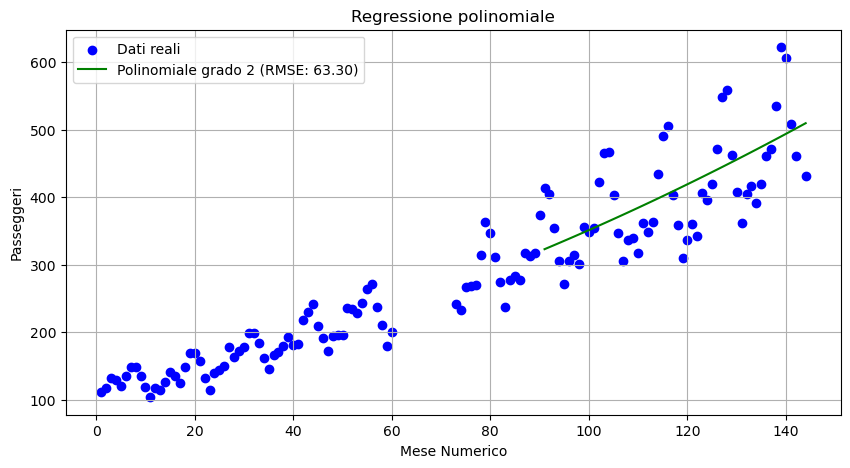

In [32]:
# grafico regressione polinomiale
plt.figure(figsize=(10, 5))
plt.scatter(X, y, label="Dati reali", color="blue")
plt.plot(X_test, y_pred_poly2, label=f"Polinomiale grado 2 (RMSE: {rmse_poly2:.2f})", color="green")
plt.xlabel("Mese Numerico")
plt.ylabel("Passeggeri")
plt.title("Regressione polinomiale")
plt.legend()
plt.grid(True)
plt.show()